In [863]:
# imports
import re
import math
import numpy as np
from collections import Counter, defaultdict
from typing import List, Dict, Tuple
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict

In [864]:
def load_raw_transcripts(path: str = TRANSCRIPTS_PATH) -> List[Dict[str, str]]:
    with open(path, "r", encoding="utf-8") as f:
        raw_text = f.read().strip()

    transcripts = []

    decoder = json.JSONDecoder()
    idx = 0
    n = len(raw_text)

    while idx < n:
        while idx < n and raw_text[idx].isspace():
            idx += 1

        if idx >= n:
            break

        obj, next_idx = decoder.raw_decode(raw_text, idx)

        transcripts.append({
            "url": obj.get("url", ""),
            "title": obj.get("title", ""),
            "content": obj.get("content", ""),
        })

        idx = next_idx

    return transcripts

In [865]:
## upload transcripts json file
import os

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
INDEX_PATH = os.path.join(DATA_DIR, "search_index.pkl")
TRANSCRIPTS_PATH = os.path.join(DATA_DIR, "4300_transcripts.json")
transcripts = load_raw_transcripts(TRANSCRIPTS_PATH)

In [866]:
transcripts[75]

{'url': 'https://scrapsfromtheloft.com/comedy/dave-chappelle-deep-heart-texas-2017-full-transcript/',
 'title': 'Dave Chappelle: Deep in the Heart of Texas (2017) – Transcript',
 'content': "[Morgan Freeman] He’s in the trance. He isn’t thinking of jokes, though. He’s composing the voiceover I’m saying to you right now. Getting me to agree to this was beyond his wildest dreams. And he doesn’t want to waste the opportunity on the frivolous. You have reached the voicemail of comedic genius Dave Chappelle. Unfortunately, he can’t or won’t speak right now, so please leave a detailed message.\n[music playing]\n♪ Play me ♪\n♪ Buy me ♪\n♪ Workinonit ♪\n♪ Tune up ♪\n♪ Tune ♪\n♪ Oh ♪\n♪ Fade me ♪\n♪ Whoo! ♪\n[music playing]\n♪ Now, when I was a young boy ♪\n♪ At the age of five ♪\n♪ My mother said I was gonna be ♪\n♪ The greatest man alive… ♪\n[cheers and applause]\n♪ But now I’m a man ♪\n♪ Way past 21 ♪\n♪ I’m a man ♪\n♪ I spell M ♪\n♪ A, child ♪\n♪ N ♪\nYeah. Thank you. Thank you very much. T

##### Transcripts restructuring

In [867]:
def parse_title_metadata(title: str) -> Tuple[str, str, str]:

    comedian = ""
    special_title = ""
    release_date = ""

    cleaned_title = re.sub(
        r"\s*[(:|–-]*\s*(Full )?Transcript\s*[):|–-]*\s*",
        "",
        title,
        flags=re.IGNORECASE
    ).strip()

    year_match = re.search(r"(?:20|19)\d\d", cleaned_title)

    if year_match:
        release_date = year_match.group()
        cleaned_title = re.sub(r"\s*[(:|–-]*\s*(20|19)\d\d\s*[):|–-]*\s*", "", cleaned_title).strip()

    if ":" in cleaned_title:
        comedian = cleaned_title.split(":", 1)[0].strip()
        special_title = cleaned_title
        # comedian, special_title = cleaned_title.split(":", 1)
        # comedian = comedian.strip()
        # special_title = special_title.strip()
    else:
        special_title = cleaned_title

    return comedian, special_title, release_date


In [868]:
def infer_platform(url: str, title: str = "") -> str:

    text = f"{url} {title}".lower()

    if "netflix" in text:
        return "Netflix"

    if "hbo" in text:
        return "HBO"

    if "comedy central" in text:
        return "Comedy Central"

    if "amazon" in text or "prime" in text:
        return "Amazon Prime"

    if "youtube" in text:
        return "YouTube"

    return ""


In [869]:
def restructure_transcripts(transcripts: List[Dict[str, str]]) -> List[Dict]:

    structured = []

    for t in transcripts:

        title = t.get("title", "")
        url = t.get("url", "")
        content = t.get("content", "")

        comedian, special_title, release_date = parse_title_metadata(title)

        structured.append({
            "url": url,
            "title": title,
            "comedian": comedian,
            "special_title": special_title,
            "release_date": release_date,
            "director": "",
            "platform": infer_platform(url, title),
            "content": content,
            "tokens": [],
            "length": 0
        })

    return structured


In [870]:
transcripts = restructure_transcripts(transcripts)

##### Cleaning

In [871]:
def bracket_if_valid(brackets: str) -> str:
    inside_str = brackets[1:-1].lower().replace('\n', '')
    if re.match(r"^((audience|crowd)( member(s)?)?|all|laughs)$", inside_str):
        return brackets
    elif re.match(r".*(applau|cheer|laugh|audience|crowd|all|clap|whoo[^sh]|music).*", inside_str):
        return ' '
    return brackets

In [872]:
bracket_if_valid('[audience members cheer]')

' '

In [873]:
def remove_bracketed_descriptions(text: str) -> str:
    return re.sub(r"\[[^\]]*\]", lambda match : bracket_if_valid(match.group()), text)


In [874]:
def normalize_text(text: str) -> str:

    text = remove_bracketed_descriptions(text)

    text = re.sub(r"‘|’", "'", text)

    text = re.sub(r"“|”", '"', text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [875]:
print(remove_bracketed_descriptions("Yo I'm [audience members] and we like to joke [laughter] [clapping] [laughter and applause]"))

Yo I'm [audience members] and we like to joke      


In [876]:
def split_transcript_into_sentences(content: str) -> List[str]:
    """
    Split transcript into sentence-like chunks.
    """
    text = normalize_text(content)

    sentences = re.split(r'(?<!\w\.\w.)(?<!\b[A-Z][a-z]\.)(?<![A-Z]\.)(?<=\.|\?)\s|\\n', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # Fallback: if a "sentence" is extremely long, split on semicolons/colons too
    refined = []
    for s in sentences:
        if len(s.split()) > 60:
            parts = re.split(r'(?<=[;:])\s+', s)
            refined.extend([p.strip() for p in parts if p.strip()])
        else:
            refined.append(s)

    return refined


##### Tokenizing Helpers

In [877]:
def tokenize(text: str) -> List[str]:

    text = text.lower()

    return re.findall(r"[a-z]+", text)


In [878]:
def vectorize_tokens(tokens, word_to_index, idf):
    """
    Convert a token list into a TF-IDF vector.
    """
    counts = Counter(tokens)
    vec = np.zeros(len(word_to_index), dtype=float)

    for term, tf in counts.items():
        if term in word_to_index and term in idf:
            vec[word_to_index[term]] = tf * idf[term]

    return vec


##### Merging Words With Spaced-Out Letters
Example: "m i d g e t" --> "midget"

In [879]:
def merge_spaced_letters(text):
    return re.sub(
        r'\b(?:[A-Za-z]\s+){1,}[A-Za-z]\b',
        lambda match: re.sub(r'\s+', '', match.group(0)),
        text
    )

##### Stop-Word Removal

In [880]:
def remove_stop_words(tokens: List[str]) -> List[str]:

    return [tok for tok in tokens if tok not in ENGLISH_STOP_WORDS]


##### FULL CLEANING PIPELINE

In [881]:
def clean_and_tokenize_text(text: str) -> List[str]:

    text = merge_spaced_letters(normalize_text(text))

    tokens = tokenize(text)

    tokens = remove_stop_words(tokens)

    return tokens


In [882]:
def clean_line_for_matching(line: str) -> List[str]:
    """
    Clean and tokenize a single line for retrieval scoring.
    """
    return clean_and_tokenize_text(line)


In [883]:
def add_clean_tokens_to_transcripts(transcripts: List[Dict]) -> List[Dict]:

    for doc in transcripts:

        toks = clean_and_tokenize_text(doc["content"])

        doc["tokens"] = toks
        doc["length"] = len(toks)

    return transcripts


In [884]:
transcripts = add_clean_tokens_to_transcripts(transcripts)

##### Corpus Stats

In [885]:
def build_word_document_count(transcripts: List[Dict]) -> Dict[str, int]:

    doc_count = Counter()

    for doc in transcripts:

        unique_tokens = set(doc["tokens"])

        doc_count.update(unique_tokens)

    return dict(doc_count)


In [886]:
def build_word_corpus_count(transcripts: List[Dict]) -> Dict[str, int]:

    corpus_count = Counter()

    for doc in transcripts:

        corpus_count.update(doc["tokens"])

    return dict(corpus_count)


In [887]:
bracketed_count = Counter()
words_count = Counter()

for doc in transcripts:
    words = re.findall(r"\[[^\]]*\]", doc['content'])
    words = list(map(lambda st : st[1:-1].lower().replace('\n', ''), words))

    bracketed_count.update(words)
    for word in words:
        words_count.update(word.split(' '))


print(bracketed_count)
print(words_count)

Counter({'laughter': 6674, 'audience laughing': 4843, 'audience laughs': 3669, 'laughs': 1476, 'chuckles': 1370, 'crowd laughing': 1096, 'laughing': 758, 'cheers and applause': 689, 'audience cheering': 650, 'applause': 619, 'crowd laughs': 541, 'cheering': 463, 'sighs': 367, 'man': 345, 'cheering and applause': 302, 'laughter and applause': 295, 'audience laughter': 272, 'audience cheers': 252, 'normal voice': 224, 'crowd cheering': 224, 'woman': 218, 'grunts': 203, 'groans': 202, 'audience chuckles': 196, 'chuckling': 185, 'audience': 150, 'audience cheering and applauding': 145, 'gasps': 121, 'bleep': 118, 'john': 114, 'audience applauding': 95, 'all laughing': 89, 'giggles': 86, 'scattered applause': 86, 'crowd cheers': 85, 'grunting': 83, 'laughter, applause': 83, 'exhales': 80, 'clicks tongue': 78, 'scoffs': 78, 'announcer': 73, 'whispers': 73, 'audience laughing and applauding': 71, 'clears throat': 70, 'audience chuckling': 70, 'cheering continues': 69, 'normal': 68, 'screams':

In [888]:
for doc in transcripts:
    match = re.search(r"\[(\w|\s)*yell(\w|\s)*\]", doc['content'], flags=re.IGNORECASE)
    if match:
        print(doc['title'])
        print(transcripts.index(doc))
        print(doc['content'][match.start()-30:match.end() + 30])

Bo Burnham: What (2013) – Transcript
21
K It’s called:
“I fuck sluts”
[audience member yells] It’s not a roll call but than
Russell Howard Live: Dingledodies (2009) – Full Transcript
45
e a lovelier thing than that? [Yells] ”Helicopter!” ”Willy Wonka, n
Kevin Hart: Zero F**ks Given (2020) – Transcript
55
les] They could barely stand. [mimics yelling] “Dad!” “We’ve been in line fo
Brian Regan: On The Rocks (2021) – Transcript
72
ilaterally decided to smother [yelling] everything you love in life…

Sarah Cooper: Everything’s Fine (2020) – Transcript
73
m complicit.
[thunder cracks]
[yells in fear]
Whoo!
The storm is coming.
I 
Fatherhood (2021) – Transcript
81
What? Jus… Matt!
[door opens]
[Marion yells in anguish] No! No! [wails]
[somber instr
Tiffany Haddish: Black Mitzvah (2019) – Transcript
89
y probably don’t know.
[gong]
[affirming yells]
[audience whoos]
[low cymbal 
Phil Wang: Philly Philly Wang Wang (2021) – Transcript
94
bs… who would come in and go: [yells] “I’m covered in bom

In [889]:
def print_top_10_common_words(transcripts: List[Dict]):

    corpus_count = build_word_corpus_count(transcripts)

    doc_count = build_word_document_count(transcripts)

    n_docs = len(transcripts)

    ranked = sorted(
        corpus_count.items(),
        key=lambda x: x[1],
        reverse=True
    )[:10]

    print("word | corpus_count | transcript_fraction")
    print("------------------------------------------")

    for word, count in ranked:

        frac = doc_count[word] / n_docs

        print(f"{word:15s} {count:10d} {frac:.4f}")


In [890]:
print_top_10_common_words(transcripts)

word | corpus_count | transcript_fraction
------------------------------------------
s                    76917 1.0000
like                 53920 1.0000
t                    48972 1.0000
m                    29538 1.0000
know                 29425 0.9979
just                 24292 0.9979
don                  24288 1.0000
right                15876 0.9936
got                  13240 0.9872
people               12708 0.9914


##### Determine thresholds for good words

In [891]:
def get_document_frequencies(transcripts):

    doc_freq = Counter()

    for doc in transcripts:
        unique_tokens = set(doc["tokens"])
        doc_freq.update(unique_tokens)

    return dict(doc_freq)


In [892]:
def plot_document_frequency_histogram(transcripts, bins=50):

    doc_freq = get_document_frequencies(transcripts)
    df_values = list(doc_freq.values())

    plt.figure(figsize=(10, 6))
    plt.hist(df_values, bins=bins, edgecolor="black")
    plt.xlabel("Document Frequency (# of transcripts containing the word)")
    plt.ylabel("Number of Words")
    plt.title("Histogram of Word Document Frequencies")
    plt.show()


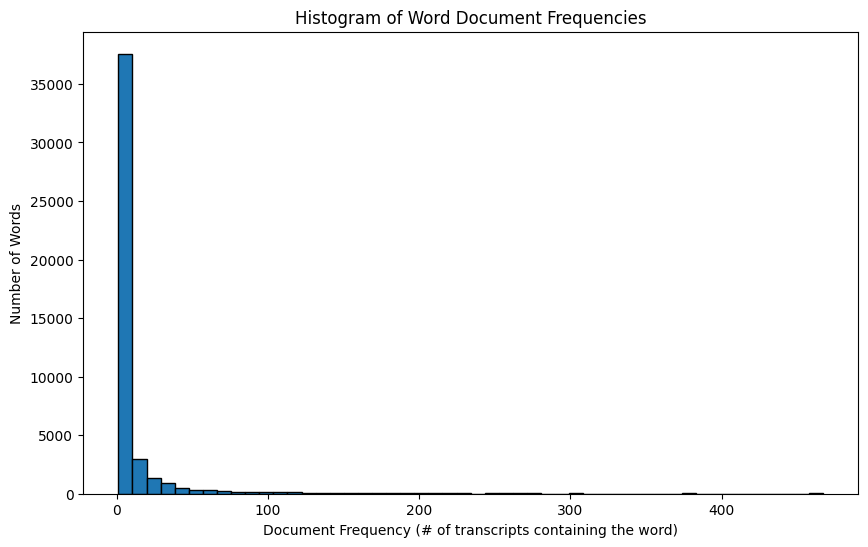

In [893]:
plot_document_frequency_histogram(transcripts)

In [894]:
def plot_document_frequency_ratio_histogram(transcripts, bins=50):

    doc_freq = get_document_frequencies(transcripts)
    n_docs = len(transcripts)

    df_ratios = [df / n_docs for df in doc_freq.values()]

    plt.figure(figsize=(10, 6))
    plt.hist(df_ratios, bins=bins, edgecolor="black")
    plt.xlabel("Document Frequency Ratio")
    plt.ylabel("Number of Words")
    plt.title("Histogram of Word Document Frequency Ratios")
    plt.show()


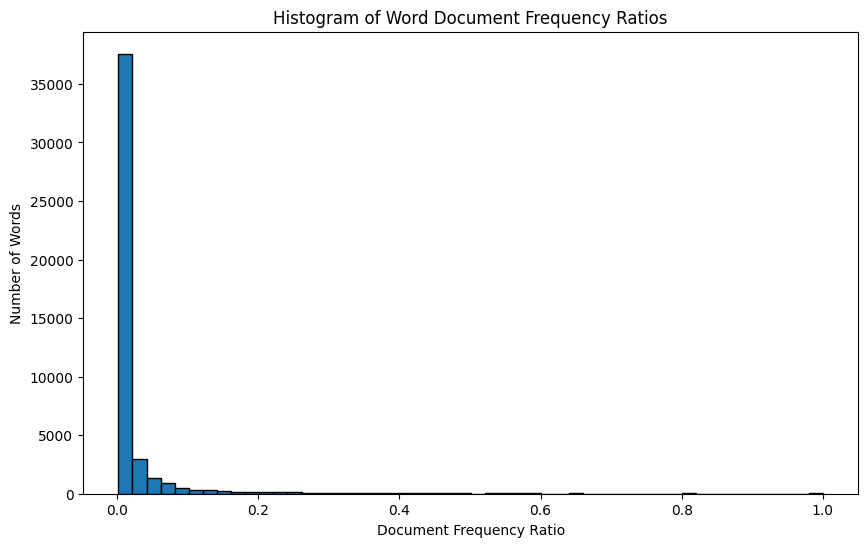

In [895]:
plot_document_frequency_ratio_histogram(transcripts)

In [896]:
def plot_sorted_document_frequencies(transcripts):

    doc_freq = get_document_frequencies(transcripts)
    sorted_dfs = sorted(doc_freq.values(), reverse=True)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(sorted_dfs) + 1), sorted_dfs)
    plt.xlabel("Words ranked by document frequency")
    plt.ylabel("Document Frequency")
    plt.title("Sorted Document Frequencies")
    plt.show()


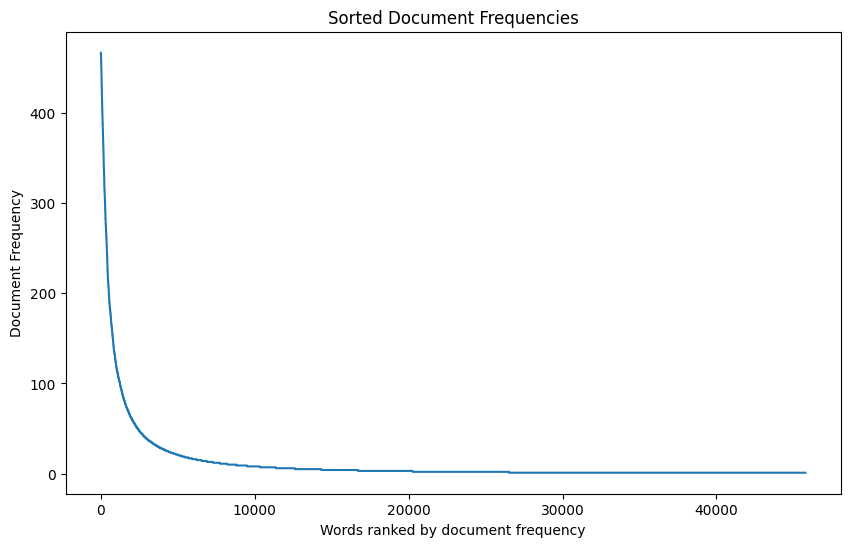

In [897]:
plot_sorted_document_frequencies(transcripts)

In [898]:
def plot_sorted_document_frequency_ratios(transcripts):

    doc_freq = get_document_frequencies(transcripts)
    n_docs = len(transcripts)

    sorted_ratios = sorted((df / n_docs for df in doc_freq.values()), reverse=True)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(sorted_ratios) + 1), sorted_ratios)
    plt.xlabel("Words ranked by document frequency ratio")
    plt.ylabel("Document Frequency Ratio")
    plt.title("Sorted Document Frequency Ratios")
    plt.show()


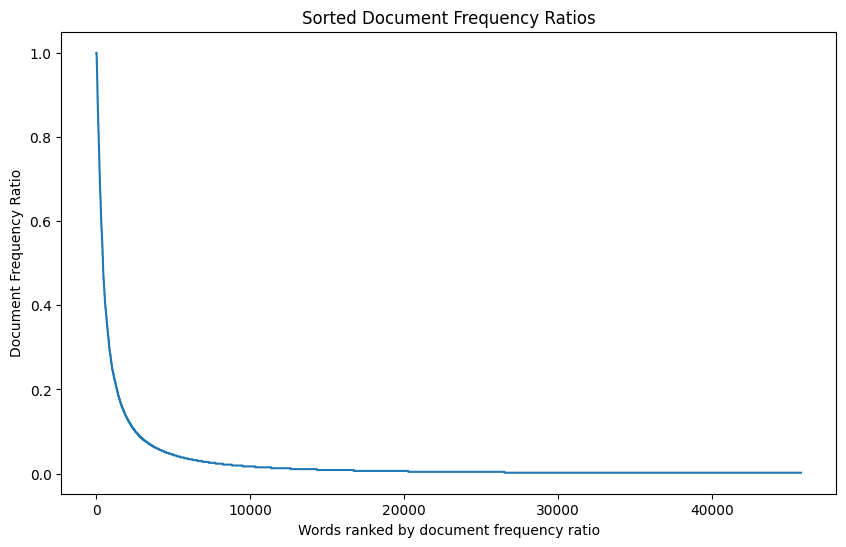

In [899]:
plot_sorted_document_frequency_ratios(transcripts)

In [900]:
def plot_document_frequency_cdf(transcripts):

    doc_freq = get_document_frequencies(transcripts)
    df_values = np.array(sorted(doc_freq.values()))

    y = np.arange(1, len(df_values) + 1) / len(df_values)

    plt.figure(figsize=(10, 6))
    plt.plot(df_values, y)
    plt.xlabel("Document Frequency")
    plt.ylabel("Cumulative Fraction of Words")
    plt.title("CDF of Document Frequencies")
    plt.show()


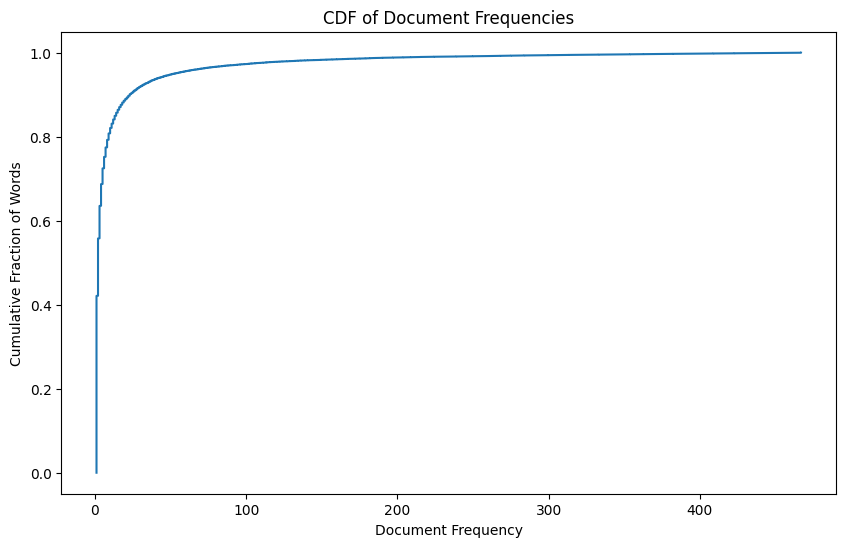

In [901]:
plot_document_frequency_cdf(transcripts)

In [902]:
def plot_document_frequency_ratio_cdf(transcripts):

    doc_freq = get_document_frequencies(transcripts)
    n_docs = len(transcripts)

    df_ratios = np.array(sorted(df / n_docs for df in doc_freq.values()))
    y = np.arange(1, len(df_ratios) + 1) / len(df_ratios)

    plt.figure(figsize=(10, 6))
    plt.plot(df_ratios, y)
    plt.xlabel("Document Frequency Ratio")
    plt.ylabel("Cumulative Fraction of Words")
    plt.title("CDF of Document Frequency Ratios")
    plt.show()


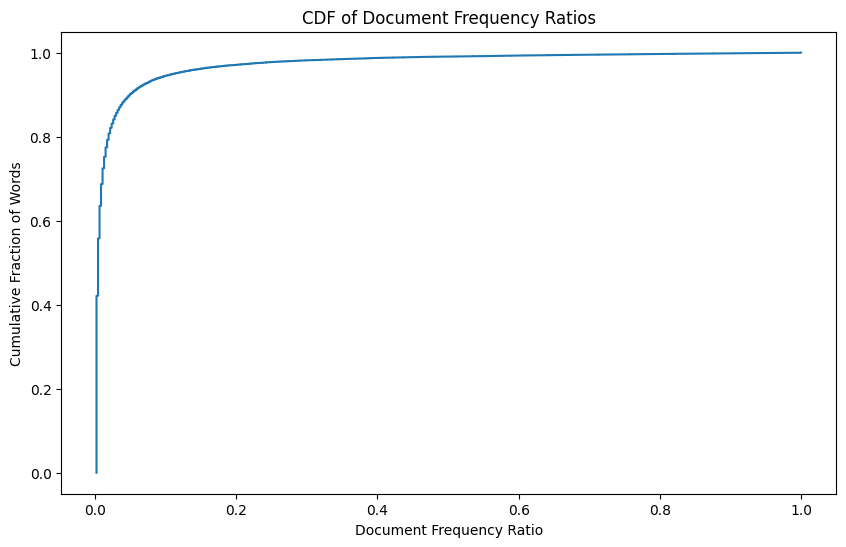

In [903]:
plot_document_frequency_ratio_cdf(transcripts)

In [904]:
def print_threshold_sweep(transcripts, min_df_values=None, max_df_ratio_values=None):

    if min_df_values is None:
        min_df_values = [1, 2, 3, 5, 10]

    if max_df_ratio_values is None:
        max_df_ratio_values = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

    doc_freq = get_document_frequencies(transcripts)
    n_docs = len(transcripts)

    print("Rare-word threshold sweep")
    print("min_df | words_kept")
    print("-------------------")
    for min_df in min_df_values:
        kept = sum(1 for df in doc_freq.values() if df >= min_df)
        print(f"{min_df:6d} | {kept:10d}")

    print("\nCommon-word threshold sweep")
    print("max_df_ratio | words_kept")
    print("-------------------------")
    for max_ratio in max_df_ratio_values:
        kept = sum(1 for df in doc_freq.values() if (df / n_docs) <= max_ratio)
        print(f"{max_ratio:12.2f} | {kept:10d}")


In [905]:
print_threshold_sweep(transcripts)

Rare-word threshold sweep
min_df | words_kept
-------------------
     1 |      45780
     2 |      26504
     3 |      20245
     5 |      14322
    10 |       8799

Common-word threshold sweep
max_df_ratio | words_kept
-------------------------
        0.50 |      45360
        0.60 |      45474
        0.70 |      45565
        0.80 |      45638
        0.90 |      45712
        0.95 |      45743


In [906]:
def plot_threshold_heatmap(
    transcripts,
    min_df_values=None,
    max_df_ratio_values=None
):

    if min_df_values is None:
        min_df_values = [1, 2, 3, 5, 10]

    if max_df_ratio_values is None:
        max_df_ratio_values = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

    doc_freq = get_document_frequencies(transcripts)
    n_docs = len(transcripts)

    heatmap = np.zeros((len(min_df_values), len(max_df_ratio_values)))

    for i, min_df in enumerate(min_df_values):
        for j, max_ratio in enumerate(max_df_ratio_values):
            kept = sum(
                1 for df in doc_freq.values()
                if df >= min_df and (df / n_docs) <= max_ratio
            )
            heatmap[i, j] = kept

    plt.figure(figsize=(10, 6))
    plt.imshow(heatmap, aspect="auto")
    plt.colorbar(label="Number of Words Kept")
    plt.xticks(range(len(max_df_ratio_values)), max_df_ratio_values)
    plt.yticks(range(len(min_df_values)), min_df_values)
    plt.xlabel("max_df_ratio")
    plt.ylabel("min_df")
    plt.title("Vocabulary Size Under Different Thresholds")
    plt.show()


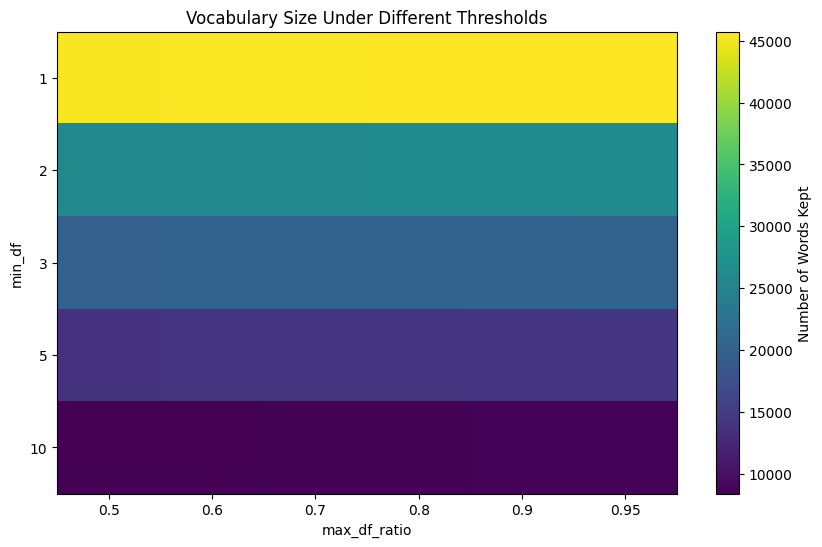

In [907]:
plot_threshold_heatmap(transcripts)

In [908]:
def plot_top_common_words_by_doc_fraction(transcripts, top_k=20):

    doc_freq = get_document_frequencies(transcripts)
    corpus_freq = build_word_corpus_count(transcripts)
    n_docs = len(transcripts)

    ranked = sorted(corpus_freq.items(), key=lambda x: x[1], reverse=True)[:top_k]

    words = [w for w, _ in ranked]
    fractions = [doc_freq[w] / n_docs for w in words]

    plt.figure(figsize=(12, 6))
    plt.bar(words, fractions)
    plt.xticks(rotation=60, ha="right")
    plt.xlabel("Word")
    plt.ylabel("Fraction of Transcripts Containing Word")
    plt.title(f"Top {top_k} Common Words by Transcript Coverage")
    plt.show()


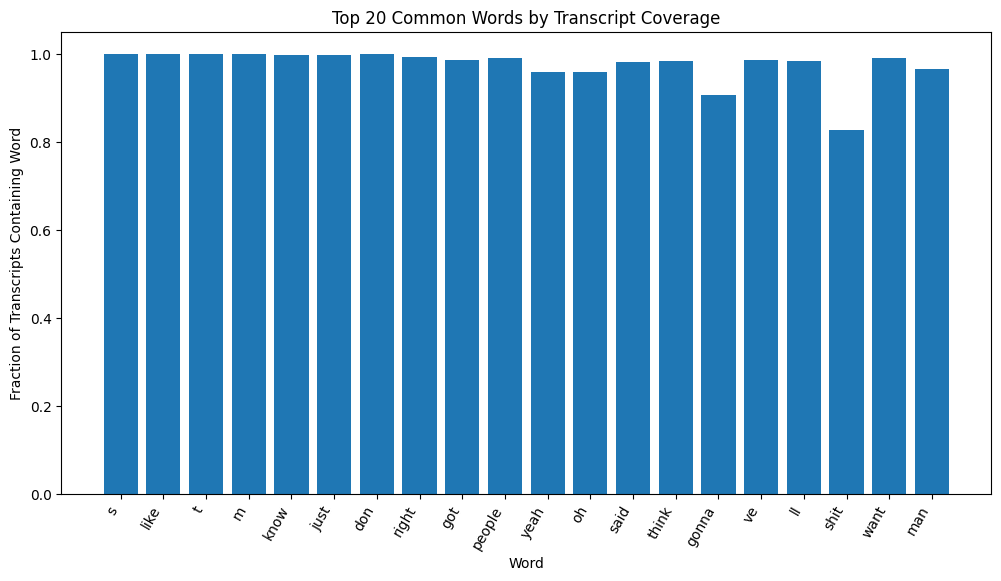

In [909]:
plot_top_common_words_by_doc_fraction(transcripts, top_k=20)

##### Build Good Words

In [910]:
def build_good_words(
    transcripts: List[Dict],
    min_df: int = 2,
    max_df_ratio: float = 0.80
):

    doc_count = build_word_document_count(transcripts)

    n_docs = len(transcripts)

    good_words = [

        word

        for word, df in doc_count.items()

        if df >= min_df and (df / n_docs) <= max_df_ratio

    ]

    return sorted(good_words)


In [911]:
good_words = build_good_words(transcripts)

In [912]:
transcripts[0]

{'url': 'https://scrapsfromtheloft.com/comedy/jeff-foxworthy-totally-committed-transcript/',
 'title': 'Jeff Foxworthy: Totally Committed (1998) – Full Transcript',
 'comedian': 'Jeff Foxworthy',
 'special_title': 'Jeff Foxworthy: Totally Committed',
 'release_date': '1998',
 'director': '',
 'platform': '',
 'content': 'Ladies and gentlemen, please welcome Jeff Foxworthy!\nThank you. Thank you very much. Nice to be back in Cincinnati! Special city special night special boots I bought new boots for the show. Can you see those? [applause from the audience] Blue stingray boots. Boots that make a statement. And that statement is… you can’t give rednecks money. [laughter] ‘Cause that’s the kind of thing we do with it. Open up a savings account? Hell no! Go buy some blue stingray boots! [laughter] A couple of weeks ago I was playing at a casino in Mississippi—which by the way is the only place in America where you can shoot craps and doves within 10 feet of each other—and I was standing off

###### Filter tokens to good words

In [913]:
def filter_tokens_to_good_words(
    transcripts: List[Dict],
    good_words: List[str]
):

    good_set = set(good_words)

    for doc in transcripts:

        filtered = [
            tok for tok in doc["tokens"]
            if tok in good_set
        ]

        doc["tokens"] = filtered

        doc["length"] = len(filtered)

    return transcripts


In [914]:
transcripts = filter_tokens_to_good_words(transcripts, good_words)

##### Build Inverted Index

In [915]:
def build_inverted_index(transcripts: List[Dict]):

    index = defaultdict(list)

    for doc_id, doc in enumerate(transcripts):

        counts = Counter(doc["tokens"])

        for term, tf in counts.items():

            index[term].append((doc_id, tf))

    return dict(index)


In [916]:
inv_idx = build_inverted_index(transcripts)

##### IDF and Norms

In [917]:
def compute_idf(
    inv_idx,
    n_docs,
    min_df=2,
    max_df_ratio=0.80
):

    idf = {}

    for term, postings in inv_idx.items():

        df = len(postings)

        if df < min_df:
            continue

        if df / n_docs > max_df_ratio:
            continue

        idf[term] = math.log((1 + n_docs) / (1 + df)) + 1

    return idf


In [918]:
idf = compute_idf(inv_idx, len(transcripts))

In [919]:
idf

{'ladies': 1.4281565193102352,
 'gentlemen': 1.7235182784362442,
 'welcome': 1.6310153994529393,
 'jeff': 3.2364452904895007,
 'foxworthy': 5.356708826689592,
 'cincinnati': 4.845883202923601,
 'special': 1.438041278542777,
 'city': 1.538996500732687,
 'boots': 3.0541237336955462,
 'bought': 1.8109302162163288,
 'blue': 1.9281124708393218,
 'stingray': 6.049856007249537,
 'statement': 2.958813553891221,
 'rednecks': 4.951243718581427,
 'money': 1.2322662333102117,
 'open': 1.251314428280906,
 'savings': 4.440418094815437,
 'account': 3.005333569526114,
 'hell': 1.4648885285789652,
 'buy': 1.4151270190199012,
 'couple': 1.328385365565285,
 'weeks': 1.5725191927713307,
 'ago': 1.2568240840918756,
 'playing': 1.441358031168771,
 'casino': 3.7144810914325004,
 'mississippi': 3.8903717578961645,
 'america': 1.5136786927483972,
 'shoot': 1.9389821430762257,
 'craps': 4.845883202923601,
 'doves': 5.069026754237811,
 'feet': 1.6974298423519463,
 'standing': 1.4994940577564408,
 'stage': 1.6804

##### VOCABULARY MAPPPING

In [920]:
def create_vocab(idf):

    vocab = sorted(idf.keys())

    word_to_index = {w: i for i, w in enumerate(vocab)}

    index_to_word = {i: w for w, i in word_to_index.items()}

    return vocab, word_to_index, index_to_word


In [921]:
vocab, word_to_index, index_to_word = create_vocab(idf)

##### Term Document Matrix

In [922]:
def create_tfidf_matrix(
    transcripts,
    word_to_index,
    idf,
    normalize_tf=False
):

    n_docs = len(transcripts)

    vocab_size = len(word_to_index)

    mat = np.zeros((n_docs, vocab_size))

    for doc_id, doc in enumerate(transcripts):

        counts = Counter(doc["tokens"])

        doc_len = len(doc["tokens"])

        for term, raw_tf in counts.items():

            if term not in word_to_index:
                continue

            if normalize_tf:

                tf = raw_tf / doc_len if doc_len else 0

            else:

                tf = raw_tf

            mat[doc_id, word_to_index[term]] = tf * idf[term]

    return mat


In [923]:
tfidf_matrix = create_tfidf_matrix(transcripts, word_to_index, idf)

In [924]:
tfidf_matrix

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [4.31525495, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(467, 26362))

##### Query Vectorization

In [925]:
def vectorize_query(query, word_to_index, idf):

    tokens = clean_and_tokenize_text(query)
    counts = Counter(tokens)

    q_vec = np.zeros(len(word_to_index))

    for term, tf in counts.items():
        if term not in word_to_index or term not in idf:
            continue

        q_vec[word_to_index[term]] = tf * idf[term]

    return q_vec



##### Cosine Retrieval

In [926]:
def retrieve_by_cosine(
    query,
    tfidf_matrix,
    transcripts,
    word_to_index,
    idf,
    top_k=10
):

    q_vec = vectorize_query(query, word_to_index, idf)
    q_norm = np.linalg.norm(q_vec)

    if q_norm == 0:
        return []

    doc_norms = np.linalg.norm(tfidf_matrix, axis=1)
    numerators = tfidf_matrix @ q_vec

    scores = []

    for doc_id in range(len(transcripts)):
        denom = doc_norms[doc_id] * q_norm

        if denom == 0:
            continue

        score = numerators[doc_id] / denom
        scores.append((score, doc_id))

    scores.sort(key=lambda x: x[0], reverse=True)
    return scores[:top_k]


In [927]:
def pretty_doc_label(doc: Dict) -> str:
    prefix = f"{doc['comedian']}: " if doc['comedian'] else ""
    return f"{prefix}{doc['special_title']} ({doc['release_date']})"

In [928]:
def print_top_transcript_results(results, transcripts):
    for rank, (score, doc_id) in enumerate(results, start=1):
        print(f"{rank}. score={score:.4f} | doc_id={doc_id} | {pretty_doc_label(transcripts[doc_id])}")


In [929]:
results = retrieve_by_cosine(
    "marriage wife kids",
    tfidf_matrix,
    transcripts,
    word_to_index,
    idf
)

print_top_transcript_results(results[:5], transcripts)

1. score=0.2030 | doc_id=218 | Seth Meyers: Seth Meyers: Lobby Baby (2019)
2. score=0.1756 | doc_id=293 | Seth Meyers: Seth Meyers: Dad Man Walking (2024)
3. score=0.1664 | doc_id=216 | Sebastian Maniscalco Stand-Up – The Tonight Show Starring Jimmy Fallon (2019)
4. score=0.1636 | doc_id=188 | Sebastian Maniscalco: Sebastian Maniscalco: Stay Hungry (2019)
5. score=0.1524 | doc_id=222 | Andy Woodhull: Andy Woodhull: You’ll Always Be Late (2019)


In [930]:
merge_spaced_letters(normalize_text(transcripts[217]['content']))

"In April 2011, Saturday Night Live's Seth Meyers hosted the star-studded White House Correspondents' Association Dinner and he wasted no time in roasting Donald Trump and other controversial media figures. I'm Seth Meyers and I cannot thank you enough for having me tonight. Let me just say up top that this evening I'm going to be making a lot of jokes about many of the people in this room, but don't worry, I assure you no matter how harsh the jokes they have all been vetted by the man at the top, Chinese President Hu Jin Tao. Truthfully, I'm humbled to be sitting at a table with President Obama, a man I greatly admire. It's such an honor to perform for the leader of the world's most powerful slash poorest country. And before I start, these were my birth certificate jokes [holds up papers] so thank you for the timing on that Mr. President. Now unusable. We were working on these jokes for months – one of my guys said 'are you worried we're a little heavy on birth certificate jokes; what

###### Sentence Retrieval

In [931]:
def find_best_matching_sentence_window(
    query: str,
    transcript: Dict,
    word_to_index: Dict[str, int],
    idf: Dict[str, float],
    match_window: int = 1
):
    """
    Find the best matching sentence window in a transcript.

    If match_window = 1, then sentence i is scored together with:
    sentence i-1, sentence i, sentence i+1

    Returns:
        best_idx, best_score, sentences
    """
    sentences = split_transcript_into_sentences(transcript["content"])

    if not sentences:
        return None, 0.0, []

    query_vec = vectorize_query(query, word_to_index, idf)
    query_norm = np.linalg.norm(query_vec)

    if query_norm == 0:
        return None, 0.0, sentences

    best_idx = None
    best_score = -1.0

    for i in range(len(sentences)):
        start = max(0, i - match_window)
        end = min(len(sentences), i + match_window + 1)

        window_text = " ".join(sentences[start:end])
        window_tokens = clean_and_tokenize_text(window_text)
        window_vec = vectorize_tokens(window_tokens, word_to_index, idf)

        denom = np.linalg.norm(window_vec) * query_norm
        if denom == 0:
            continue

        score = np.dot(window_vec, query_vec) / denom

        if score > best_score:
            best_score = score
            best_idx = i

    return best_idx, best_score, sentences


In [932]:
def get_sentence_context(sentences, center_idx, window=3):
    """
    Return sentences from center_idx - window through center_idx + window.
    """
    if center_idx is None:
        return []

    start = max(0, center_idx - window)
    end = min(len(sentences), center_idx + window + 1)

    return sentences[start:end]


In [933]:
def retrieve_top_transcripts_with_sentence_context(
    query: str,
    transcripts: List[Dict],
    tfidf_matrix: np.ndarray,
    word_to_index: Dict[str, int],
    idf: Dict[str, float],
    top_k: int = 5,
    context_window: int = 3,
    match_window: int = 1
):
    """
    Stage 1:
        retrieve top_k transcripts using transcript-level cosine similarity

    Stage 2:
        inside each transcript, find the best matching sentence window

    Returns:
        transcript metadata + best local sentence context
    """
    top_docs = retrieve_by_cosine(
        query=query,
        tfidf_matrix=tfidf_matrix,
        transcripts=transcripts,
        word_to_index=word_to_index,
        idf=idf,
        top_k=top_k
    )

    results = []

    for transcript_score, doc_id in top_docs:
        transcript = transcripts[doc_id]

        best_idx, sentence_score, sentences = find_best_matching_sentence_window(
            query=query,
            transcript=transcript,
            word_to_index=word_to_index,
            idf=idf,
            match_window=match_window
        )

        context_sentences = get_sentence_context(
            sentences,
            best_idx,
            window=context_window
        )

        best_sentence = (
            sentences[best_idx]
            if best_idx is not None and 0 <= best_idx < len(sentences)
            else ""
        )

        results.append({
            "doc_id": doc_id,
            "transcript_score": transcript_score,
            "sentence_score": sentence_score,
            "title": transcript["title"],
            "comedian": transcript["comedian"],
            "special_title": transcript["special_title"],
            "release_date": transcript["release_date"],
            "best_sentence_index": best_idx,
            "best_sentence": best_sentence,
            "context_sentences": context_sentences
        })

    return results

In [934]:
def print_sentence_retrieval_results(results):
    for rank, result in enumerate(results, start=1):
        print("=" * 100)
        print(f"Rank {rank}")
        print(f"Title: {result['title']}")
        print(f"Comedian: {result['comedian']}")
        print(f"Special: {result['special_title']}")
        print(f"Year: {result['release_date']}")
        print(f"Transcript score: {result['transcript_score']:.4f}")
        print(f"Sentence score: {result['sentence_score']:.4f}")
        print(f"Best sentence index: {result['best_sentence_index']}")
        print("-" * 100)

        for sentence in result["context_sentences"]:
            print(sentence)

        print()


In [935]:
def run_query(
    query: str,
    transcripts: List[Dict],
    tfidf_matrix: np.ndarray,
    word_to_index: Dict[str, int],
    idf: Dict[str, float],
    top_k: int = 5,
    context_window: int = 3,
    match_window: int = 1
):
    results = retrieve_top_transcripts_with_sentence_context(
        query=query,
        transcripts=transcripts,
        tfidf_matrix=tfidf_matrix,
        word_to_index=word_to_index,
        idf=idf,
        top_k=top_k,
        context_window=context_window,
        match_window=match_window
    )

    print_sentence_retrieval_results(results)
    return results


In [936]:
results = run_query(
    query="marriage wife kids family",
    transcripts=transcripts,
    tfidf_matrix=tfidf_matrix,
    word_to_index=word_to_index,
    idf=idf,
    top_k=5,
    context_window=1,
    match_window=1
)


Rank 1
Title: Seth Meyers: Lobby Baby (2019) – Full Transcript
Comedian: Seth Meyers
Special: Seth Meyers: Lobby Baby
Year: 2019
Transcript score: 0.2030
Sentence score: 0.3479
Best sentence index: 401
----------------------------------------------------------------------------------------------------
You agree with me, too.
I've been, uh, living with my wife now for ten years.
We've lived together for ten years, and let me tell you, my wife has made my life just immeasurably better.

Rank 2
Title: Seth Meyers: Dad Man Walking (2024) | Transcript
Comedian: Seth Meyers
Special: Seth Meyers: Dad Man Walking
Year: 2024
Transcript score: 0.1756
Sentence score: 0.5345
Best sentence index: 500
----------------------------------------------------------------------------------------------------
I do have a mean wife.
You guys– But only to me.
My wife is mean to me, and she is so nice to the kids, and that is so much better than the other way around.

Rank 3
Title: Sebastian Maniscalco Stand-Up

##### Rocchio Query Update

In [937]:
def rocchio_update(
    query_vector,
    relevant_doc_ids,
    irrelevant_doc_ids,
    tfidf_matrix,
    alpha=1.0,
    beta=0.75,
    gamma=0.15
):

    q_new = alpha * query_vector.copy()

    if relevant_doc_ids:

        rel_centroid = np.mean(
            tfidf_matrix[relevant_doc_ids],
            axis=0
        )

        q_new += beta * rel_centroid

    if irrelevant_doc_ids:

        irrel_centroid = np.mean(
            tfidf_matrix[irrelevant_doc_ids],
            axis=0
        )

        q_new -= gamma * irrel_centroid

    q_new = np.maximum(q_new, 0)

    return q_new
